In [1]:
import os
from mne import read_epochs
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

In [2]:
# sns.set(font_scale=1.5)
sns.set_style('ticks')

plt.rcParams['axes.titlesize'] = 11 # 24
plt.rcParams['axes.labelsize'] = 10 # 22
plt.rcParams['xtick.labelsize'] = 9 # 20
plt.rcParams['ytick.labelsize'] = 9 # 20
plt.rcParams['legend.fontsize'] = 8 # 18
plt.rcParams['legend.title_fontsize'] = 9 # 20


# Saccade Analysis

In [3]:
# df = pd.read_parquet('../results/saccade_summary.parquet')

In [4]:
eeg_dir = '/home/nmuller/projects/fmg_projects/2024_Scholte_FMG-6506_oads_res/oads_resolution_experiment/data_SECOND_BATCH/fif_files/sub017_ses001size3-OC-epo.fif'

epochs = read_epochs(fname=eeg_dir, preload=False)

n_channels = len(epochs.ch_names)
n_timepoints = len(epochs.times)
sample_rate = 1024
t = [i/sample_rate - 0.1 for i in range(n_timepoints)]

channel_names = epochs.ch_names
# visual_channel_names = ['O1', 'O2', 'Oz', 'Iz', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'PO3', 'PO7', 'POz', 'PO4', 'PO8', 'F5', 'F6']
visual_channel_names = ['O1', 'O2', 'Oz', 'P1', 'P2', 'P3', 'P4', 'P5', 'P6', 'P7', 'P8', 'PO3', 'PO7', 'POz', 'Pz', 'PO4', 'PO8'] # , 'I1', 'I2', 'Iz'
visual_channel_indices = [channel_names.index(ch) for ch in visual_channel_names if ch in channel_names]
print(len(visual_channel_indices))

Reading /home/nmuller/projects/fmg_projects/2024_Scholte_FMG-6506_oads_res/oads_resolution_experiment/data_SECOND_BATCH/fif_files/sub017_ses001size3-OC-epo.fif ...


    Found the data of interest:
        t =     -99.61 ...     400.39 ms
        0 CTF compensation matrices available
Not setting metadata
616 matching events found
No baseline correction applied
0 projection items activated
17


In [ ]:
# cols = ['folder', 'eye_reject', 'subject', 'model_type', 'exp_condition', 'layer', 'image_representation', 'image_quality', 'n_pca_components', 'resolution', 'crop_condition', 'crop_instance', 'fraction', 'channel', 'channel_index', 'timepoint', 'timepoint_index', 'pred_index', 'metric', 'value']
# dtypes = {col: 'category' for col in cols if col != 'value'}
# sample_rate = 1024
# n_timepoints = 513
# result_dir = '/home/nmuller/projects/fmg_storage/oads_resolution_eeg_analysis/' # 400_pixels/

# remove_low_acc = False
# manual = True
# # eye_reject = True

# mode = '_drop_low_acc' if remove_low_acc else ('_manual' if manual else '')

# rows = []

# for sub in [12, 15, 16, 17, 18, 19]: #  12, 15, 16, 17, 18, 19
#     # for exp_condition in ['size1', 'size2', 'size3']: # 'size1', 'size2', 'size3', , 'center1', 'center2', 'center3', 'peri1', 'peri2', 'peri3'
#     # for exp_condition in ['size1', 'size2', 'size3']: # 'size1', 'size2', 'size3', 'center1', 'center2', 
#     for exp_condition in ['center1', 'peri1']: # 'size1', 'size2', 'size3', 'center1', 'center2', 'peri1', 'peri2', 'peri3'

#         for eye_reject in [False, True]:
        
#             folder = f'encoding{mode}{"eye_reject" if eye_reject else ""}_alexnet_imagenet_share-pca_partial-corr_feature-cropping-AutoReject_{exp_condition}'
#             result_manager = ResultManager(root=os.path.join(result_dir, folder))

#             # rows = []
#             # rows_pca = []
#             for image_representation in ['rgb']:
#                 for image_quality in ['raw']: 
#                     for n_pca_components in [100]: 
#                         for model_type in ['alexnet_imagenet']: # alexnet_scce_full-crop
#                             for layer in ['across-layers']: # f'{model_type}_layer1',f'{model_type}_layer2',f'{model_type}_layer3', 
#                             # for layer in tqdm.tqdm(['across-layers'], total=1):
#                                 for image_resolution in ['400']: # '_400'
#                                     # for crop_condition in ['gcs', 'gcs_inverse', 'fraction']:
#                                     # for exp_condition in ['size1', 'size2', 'size3']: # 
#                                     for exp_condition in [exp_condition]:
#                                         for crop_condition in ['feature', 'gcs']: # 'feature', 'gcs', 'gcs_inverse', 'fraction', , 'fraction'

#                                             # crop_instances = ['gcs-full'] if 'gcs' in crop_condition else (['center', 'periphery', 'center_circ', 'periphery_circ'] if 'fraction' in crop_condition else ['feature-full'])
#                                             crop_instances = ['gcs-full'] if 'gcs' in crop_condition else ['feature-full']
#                                             fractions = [1.0] #if 'gcs' in crop_condition or 'feature' in crop_condition else [0.05] #  , 0.01, 0.05, 0.1, 0.2

#                                             for fraction in fractions:
#                                                 for crop_instance in crop_instances:


#                                                     results = result_manager.load_result(filename=f'encoding_results_pca_{n_pca_components}_sub_{sub}_{model_type}_{exp_condition}_feature-cropping_{layer}_{image_representation}_{image_quality}_{image_resolution}_{crop_condition}_{crop_instance}_{fraction}.pkl')
#                                                     folder = result_manager.root

#                                                     if results is not None:
#                                                         if 'timepoints' in results.keys():
#                                                             timepoints = range(len(results['timepoints']))
                                                            
#                                                         else:
#                                                             timepoints = None

#                                                         if 't' in results.keys():
#                                                             t = results['t']
#                                                         else:
#                                                             t = [i/sample_rate - 0.1 for i in range(n_timepoints)]

#                                                         for channel in results['corr_channels'].keys():
#                                                             if timepoints is None:
#                                                                 timepoints = range(len(results['corr_channels'][channel]))

#                                                             for timepoint in timepoints:

#                                                                 r2_train = results['corr_channels'][channel][timepoint]
#                                                                 rows.append([folder, eye_reject, sub, model_type, exp_condition, layer, image_representation, image_quality, n_pca_components, image_resolution, crop_condition, crop_instance, fraction, channel, channel, t[timepoint], timepoint, -1, 'corr_train', r2_train])

#                                                                 test_corr_train = results['test_corr_channels'][channel][timepoint]
#                                                                 rows.append([folder, eye_reject, sub, model_type, exp_condition, layer, image_representation, image_quality, n_pca_components, image_resolution, crop_condition, crop_instance, fraction, channel, channel, t[timepoint], timepoint, -1, 'test_corr_train', test_corr_train])
                                                            

In [ ]:
# df = pd.DataFrame(data=rows, columns=cols)

In [5]:
# df.to_parquet('/home/nmuller/projects/fmg_storage/oads_resolution_eeg_analysis/eye_movement_comparison_encoding_performances_alexnet_imagenet_center-peri.parquet', index=False)
df = pd.read_parquet('/home/nmuller/projects/fmg_storage/oads_resolution_eeg_analysis/eye_movement_comparison_encoding_performances_alexnet_imagenet_center-peri.parquet')

In [ ]:
# other_df = pd.read_parquet('/home/nmuller/projects/fmg_storage/oads_resolution_eeg_analysis/encoding_manual_alexnet_imagenet_share-pca_partial-corr_feature-cropping-AutoReject_center-peri.parquet')
# df.to_parquet('/home/nmuller/projects/fmg_storage/oads_resolution_eeg_analysis/encoding_eye_reject-accepted_alexnet_imagenet_share-pca_partial-corr_feature-cropping-AutoReject_center-peri.parquet')

In [8]:
from scipy.stats import wilcoxon

def plot_max_timepoints(_df, ax, y=0.3):
    center_timepoints = _df.loc[_df[(_df['Aperture'] == 'Center') & (_df['timepoint'] > 0)].groupby('subject').value.idxmax()].timepoint.values #   & (_df['timepoint'] < 0.2)
    periphery_timepoints = _df.loc[_df[(_df['Aperture'] == 'Periphery') & (_df['timepoint'] > 0)].groupby('subject').value.idxmax()].timepoint.values #   & (_df['timepoint'] < 0.2)

    # center_timepoints = []
    # periphery_timepoints = []
    # for sub in _df.subject.unique():
    #     _x_center = _df[(_df['Aperture'] == 'Center') & (_df['subject'] == sub) & (_df['timepoint'] > 0)]
    #     _x_peri = _df[(_df['Aperture'] == 'Periphery') & (_df['subject'] == sub) & (_df['timepoint'] > 0)]

    #     if _x_center.value.max() > _x_center.value.mean() + 2*_x_center.value.std() and _x_peri.value.max() > _x_peri.value.mean() + 2*_x_peri.value.std():
    #         # if _x_center.timepoint[_x_center.value.idxmax()] > 0.3:
    #         #     print(sub, _x_center.timepoint[_x_center.value.idxmax()])
    #         center_timepoints.append(_x_center.timepoint[_x_center.value.idxmax()])
    #         periphery_timepoints.append(_x_peri.timepoint[_x_peri.value.idxmax()])

            
    # center_timepoints = _df.loc[_df[(_df['Aperture'] == 'Center')].groupby('subject').value.idxmax()].timepoint.values
    # periphery_timepoints = _df.loc[_df[(_df['Aperture'] == 'Periphery')].groupby('subject').value.idxmax()].timepoint.values

    # mask = (center_timepoints > 0) & (periphery_timepoints > 0)
    # center_timepoints = center_timepoints[mask]
    # periphery_timepoints = periphery_timepoints[mask]

    # print(center_timepoints)
    # y = 0.3
    parts = ax.violinplot(center_timepoints, positions=[y], vert=False, widths=0.15, showmedians=True, showextrema=False, side='high')
    parts['cmedians'].set_color('C1')
    for p in parts['bodies']:
        p.set_facecolor('C1')
        p.set

    for _x in center_timepoints:
        ax.text(_x, y+0.01, '*', fontsize=8, color='C1', ha='center', va='center', alpha=0.5)

    parts = ax.violinplot(periphery_timepoints, positions=[y], vert=False, widths=0.15, showmedians=True, showextrema=False, side='high')
    parts['cmedians'].set_color('C0')
    for p in parts['bodies']:
        p.set_facecolor('C0')

    for _x in periphery_timepoints:
        ax.text(_x, y, '*', fontsize=8, color='C0', ha='center', va='center', alpha=0.5)

    # stat = wilcoxon(center_timepoints, periphery_timepoints)
    # is_sig = stat.pvalue < 0.05

    # # draw a horizontal line between the two medians of the violins with small vertical extensions
    # y += 0.09
    # ax.plot([np.median(center_timepoints), np.median(periphery_timepoints)], [y, y], color='black', linewidth=2)
    # ax.plot([np.median(center_timepoints), np.median(center_timepoints)], [y-0.0075, y+0.0075], color='black', linewidth=2)
    # ax.plot([np.median(periphery_timepoints), np.median(periphery_timepoints)], [y-0.0075, y+0.0075], color='black', linewidth=2)
    # ax.text((np.median(center_timepoints) + np.median(periphery_timepoints))/2, y+0.03, '*' if is_sig else 'NS', fontsize=30 if is_sig else 18, color='black', ha='center', va='center')

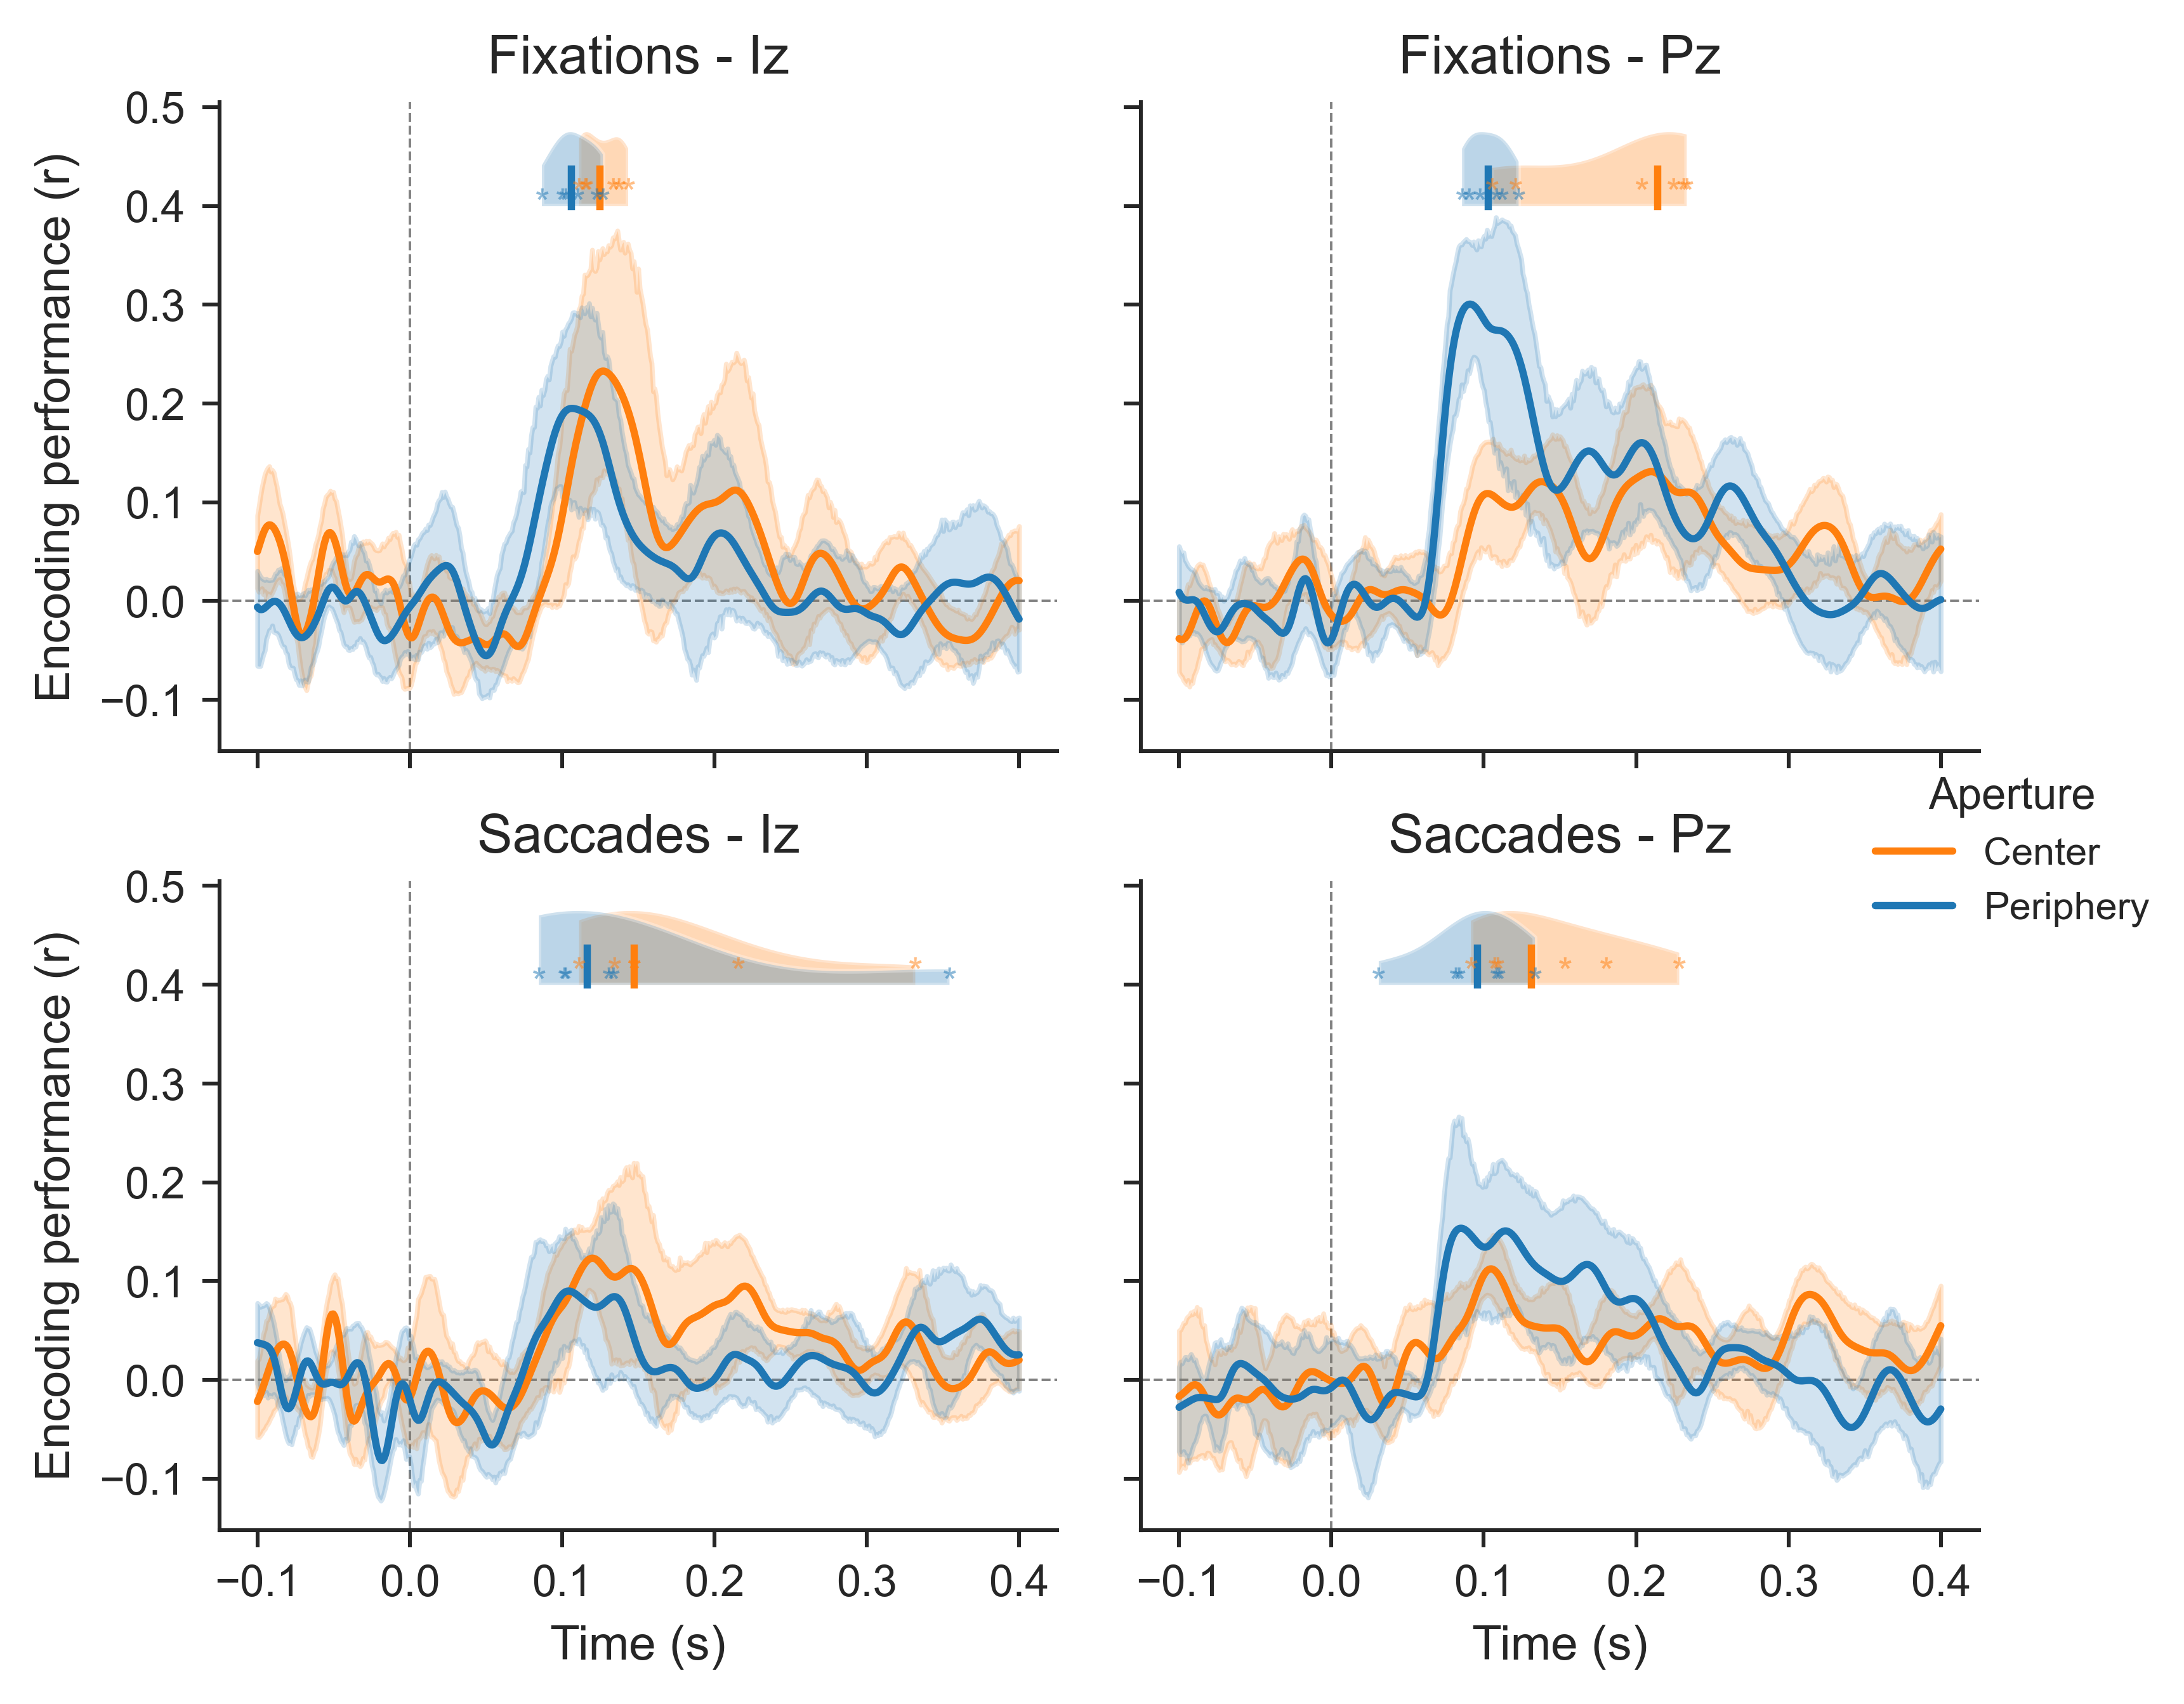

In [13]:
# g = sns.relplot(data=df[(df['metric'] == 'test_corr_train') & (df['crop_condition'] == 'feature') & (df['channel_index'].isin([channel_names.index(ch) for ch in visual_channel_names]))].reset_index(), x='timepoint', y='value', col='eye_reject', hue='exp_condition', kind='line')
# g = sns.relplot(data=df[(df['metric'] == 'test_corr_train') & (df['crop_condition'] == 'feature') & (df['channel_index'].isin([channel_names.index(ch) for ch in visual_channel_names]))].reset_index(), x='timepoint', y='value', col='subject', row='eye_reject', hue='exp_condition', kind='line')
# g = sns.relplot(data=df[(df['metric'] == 'test_corr_train') & (df['channel_index'].isin([channel_names.index(ch) for ch in visual_channel_names]))].reset_index(), x='timepoint', y='value', style='crop_condition', col='eye_reject', hue='exp_condition', kind='line')


# g = sns.relplot(data=df[(df['metric'] == 'test_corr_train') & (df['crop_condition'] == 'feature') & (df['channel_index'].isin([channel_names.index(ch) for ch in ['Iz']]))].reset_index(), x='timepoint', y='value', col='subject', row='eye_reject', hue='exp_condition', kind='line')
# g = sns.relplot(data=df[(df['metric'] == 'test_corr_train') & (df['crop_condition'] == 'feature') & (df['channel_index'].isin([channel_names.index(ch) for ch in ['Oz']]))].reset_index(), x='timepoint', y='value', row='eye_reject', hue='exp_condition', kind='line')
_data = df[(df['metric'] == 'test_corr_train') & (df['crop_condition'] == 'feature') & (df['channel_index'].isin([channel_names.index(ch) for ch in ['Iz', 'Pz']]))].reset_index().copy()
_data['exp_condition'] = _data['exp_condition'].str.replace('center1', 'Center').replace('peri1', 'Periphery')
_data['eye_reject'] = _data['eye_reject'].replace({False: 'Fixations', True: 'Saccades'})
_data = _data.rename(columns={'exp_condition': 'Aperture'})

colormap = {
    'Center': 'C1',
    'Periphery': 'C0',
}

g = sns.relplot(data=_data, x='timepoint', y='value', col='channel', row='eye_reject', hue='Aperture', kind='line', palette=colormap)

plot_channels = ['Iz', 'Pz']
conditions = ['Fixations', 'Saccades']

for row_index in range(len(g.axes)):
    for col_index in range(len(g.axes[row_index])):
        ch = plot_channels[col_index]
        cond = conditions[row_index]

        plot_max_timepoints(_df=_data[(_data['channel'] == channel_names.index(ch)) & (_data['eye_reject'] == cond)], ax=g.axes[row_index][col_index], y=0.4)

        ax = g.axes[row_index][col_index]
        ax.axvline(x=0, color='gray', linestyle='--', linewidth=0.5, zorder=-10)
        ax.axhline(y=0, color='gray', linestyle='--', linewidth=0.5, zorder=-10)
        ax.set_title(f"{cond} - {ch}", y=1.0) # if row_index == 0 else f"Saccades - {ch}")
        ax.set_xlabel('Time (s)')
        ax.set_ylabel('Encoding performance (r)')

figure_dir = '/home/nmuller/projects/fmg_storage/tux20_oads_eeg_paper_figures/publication_figures'

# g.figure.set_size_inches(18, 10)
g.figure.set_size_inches(6, 4.5)
g.figure.set_dpi(550)
g.figure.subplots_adjust(wspace=0.1, hspace=0.2)

g.figure.savefig(os.path.join(figure_dir, 'S5B Figure Eye-tracking data analysis.tif'), bbox_inches='tight', dpi=550, pil_kwargs=dict(compression='tiff_lzw'))
g.figure.savefig(os.path.join(figure_dir, 'S5B Figure Eye-tracking data analysis.pdf'), bbox_inches='tight', dpi=550)
plt.show()